<a href="https://colab.research.google.com/github/olifviazhry/projectportofolio/blob/main/Used%20Cars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
# loading the csv data to a Pandas DataFrame
cars_data = pd.read_csv('/content/train.csv')

In [ ]:
cars = pd.DataFrame(cars_data)

In [ ]:
cars

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188528,188528,Cadillac,Escalade ESV Platinum,2017,49000,Gasoline,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Beige,None reported,Yes,27500
188529,188529,Mercedes-Benz,AMG C 43 AMG C 43 4MATIC,2018,28600,Gasoline,385.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,White,Black,At least 1 accident or damage reported,Yes,30000
188530,188530,Mercedes-Benz,AMG GLC 63 Base 4MATIC,2021,13650,Gasoline,469.0HP 4.0L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Black,None reported,Yes,86900
188531,188531,Audi,S5 3.0T Prestige,2022,13895,Gasoline,3.0L,1-Speed Automatic,Daytona Gray Pearl Effect,Black,None reported,NaN,84900


In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

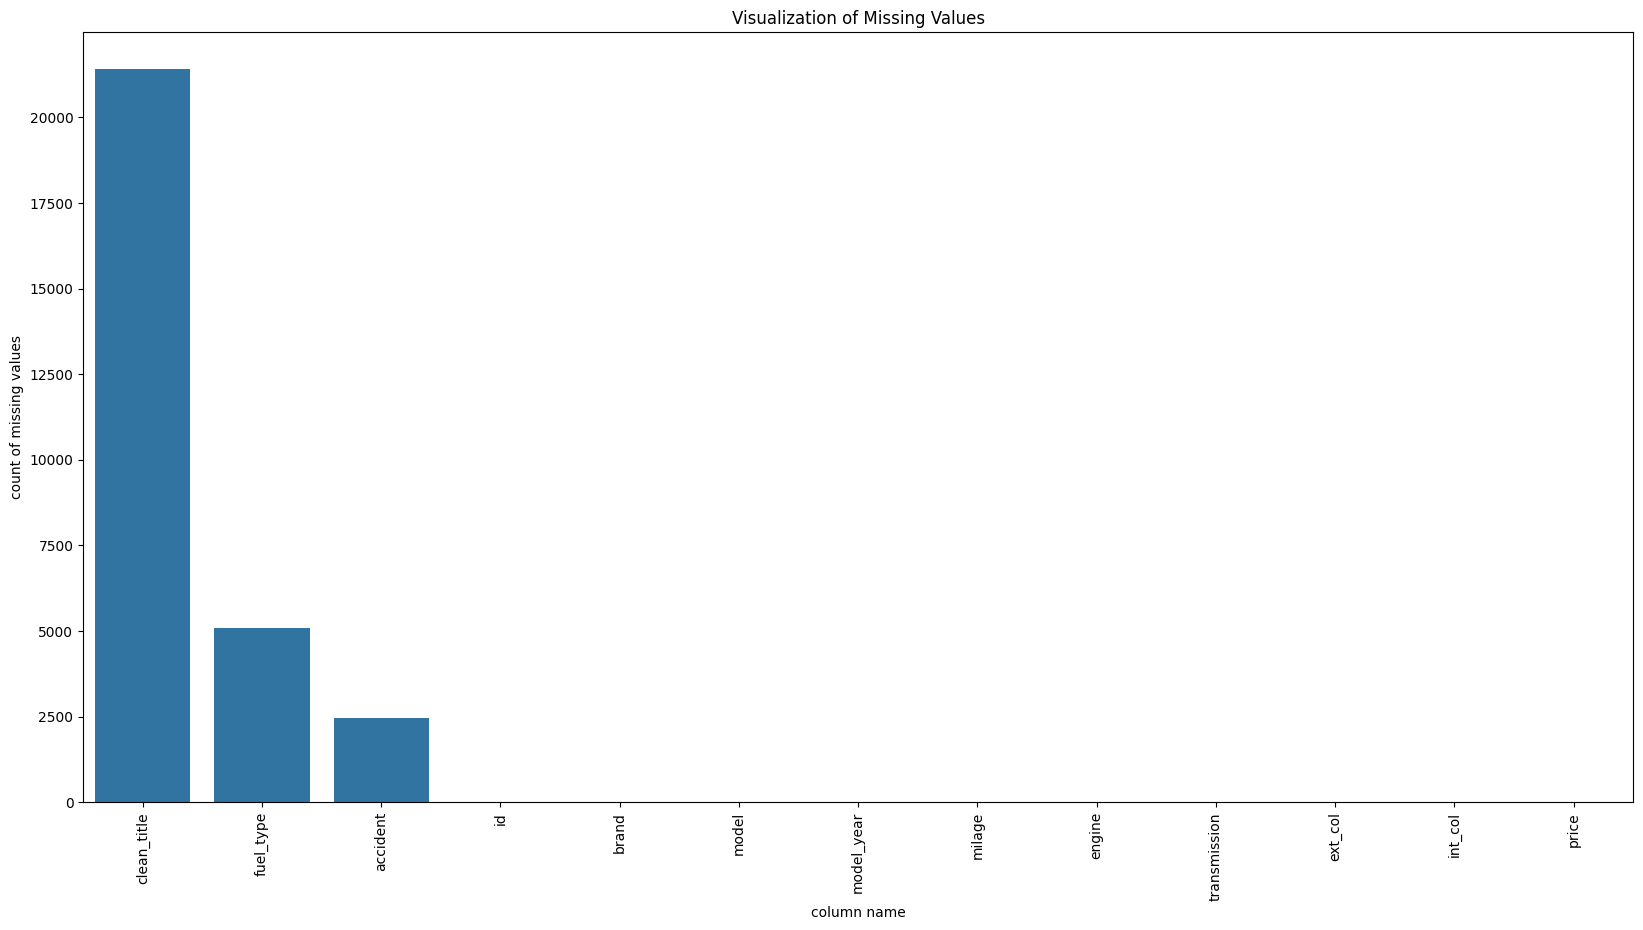

In [ ]:

# Menghitung jumlah missing values per kolom
missing_values = cars.isnull().sum().sort_values(ascending=False)

# Membuat bar plot untuk visualisasi
plt.figure(figsize=(20, 10))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xlabel('column name')
plt.ylabel('count of missing values')
plt.title('Visualization of Missing Values')
plt.xticks(rotation=90)
plt.show()

Conclusion

Terdapat 3 kolom yang memiliki missing value
1. clean title

2. fuel type

3. accident

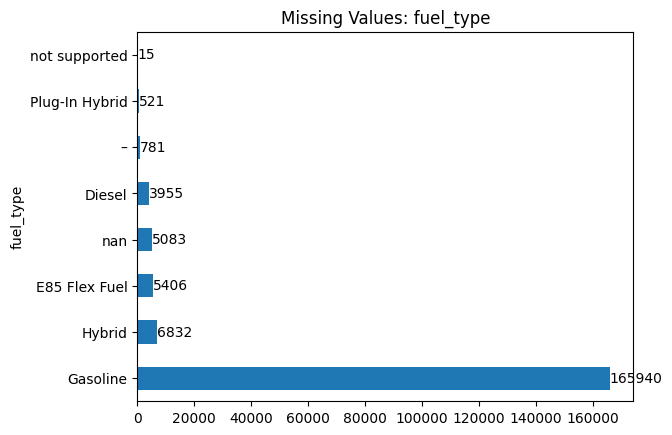

In [ ]:
##CEK MISSING VALUE DI FUEL TYPE##

ax = cars["fuel_type"].value_counts(dropna = False).plot(kind = "barh")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Missing Values: fuel_type");

bahan bakar yang paling banyak digunakan adalah gasoline atau bensin sedangkan terdapat bahan bakar yang not supported dan juga ada yang di -, maka untuk missing value pada fuel type akan diisi dengan 'unknown'

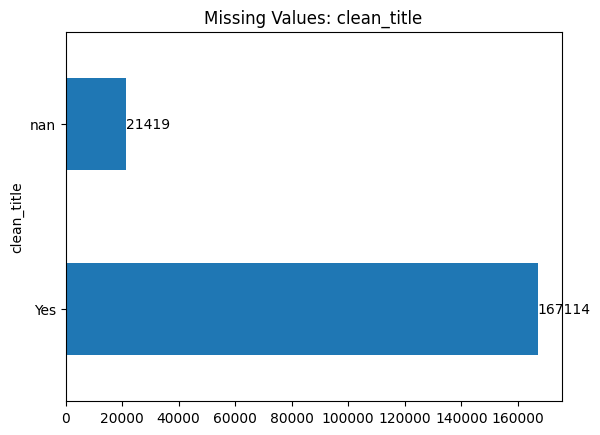

In [ ]:
##CEK MISSING VALUE PADA KOLOM CLEAN TITLE##

ax = cars["clean_title"].value_counts(dropna = False).plot(kind = "barh")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Missing Values: clean_title");

terdapat missing value dengan nilai nan sehingga bisa diubah ke No

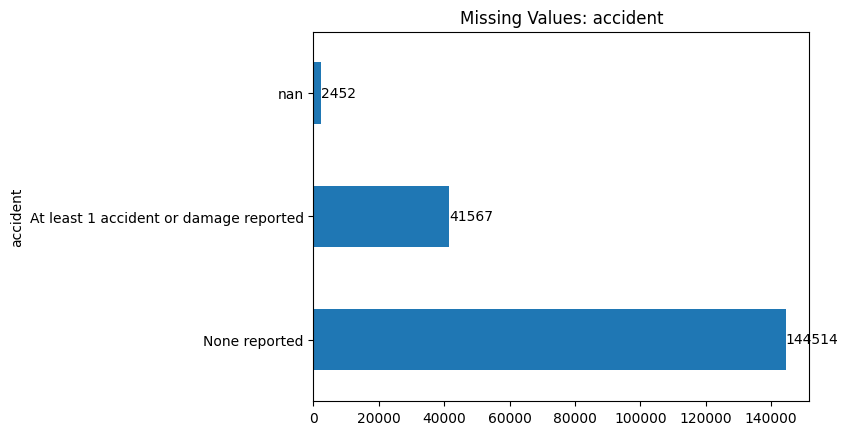

In [ ]:
##CEK MISSING VALUE PADA KOLOM ACCIDENT##

ax = cars["accident"].value_counts(dropna = False).plot(kind = "barh")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Missing Values: accident");

terdapat missing value pada kkolom accident dan akan digantikan dengan 'unknown data'

*HANDLING MISSING VALUE*

In [ ]:
cars["accident"] = cars["accident"].fillna("unknown data")
cars["clean_title"] = cars["clean_title"].fillna("No")

<Axes: xlabel='model_year'>

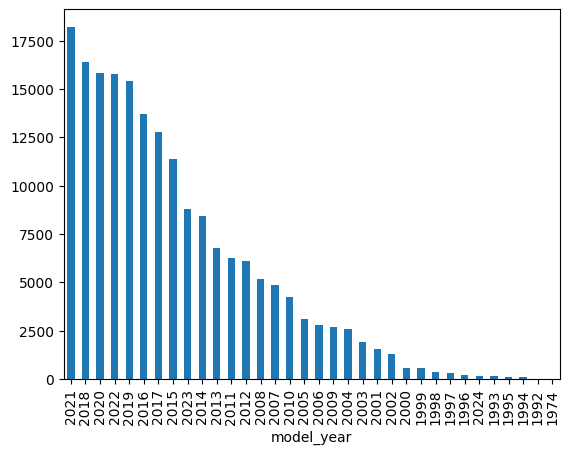

In [ ]:
cars["model_year"].value_counts().plot(kind= "bar")

In [ ]:
##cars.replace({'fuel_type': {'–': 'NaN'}}, inplace=True)
##print(cars)

            id          brand                     model  model_year  milage  \
0            0           MINI             Cooper S Base        2007  213000   
1            1        Lincoln                     LS V8        2002  143250   
2            2      Chevrolet         Silverado 2500 LT        2002  136731   
3            3        Genesis          G90 5.0 Ultimate        2017   19500   
4            4  Mercedes-Benz               Metris Base        2021    7388   
...        ...            ...                       ...         ...     ...   
188528  188528       Cadillac     Escalade ESV Platinum        2017   49000   
188529  188529  Mercedes-Benz  AMG C 43 AMG C 43 4MATIC        2018   28600   
188530  188530  Mercedes-Benz    AMG GLC 63 Base 4MATIC        2021   13650   
188531  188531           Audi          S5 3.0T Prestige        2022   13895   
188532  188532        Porsche                Macan Base        2016   59500   

            fuel_type                              

In [ ]:
cars['fuel_type'] = cars['fuel_type'].fillna('–')

print(cars)

            id          brand                     model  model_year  milage  \
0            0           MINI             Cooper S Base        2007  213000   
1            1        Lincoln                     LS V8        2002  143250   
2            2      Chevrolet         Silverado 2500 LT        2002  136731   
3            3        Genesis          G90 5.0 Ultimate        2017   19500   
4            4  Mercedes-Benz               Metris Base        2021    7388   
...        ...            ...                       ...         ...     ...   
188528  188528       Cadillac     Escalade ESV Platinum        2017   49000   
188529  188529  Mercedes-Benz  AMG C 43 AMG C 43 4MATIC        2018   28600   
188530  188530  Mercedes-Benz    AMG GLC 63 Base 4MATIC        2021   13650   
188531  188531           Audi          S5 3.0T Prestige        2022   13895   
188532  188532        Porsche                Macan Base        2016   59500   

            fuel_type                              

In [ ]:
handling_missing_value = cars[cars['fuel_type'] == '–'][['model', 'engine']]
print(handling_missing_value)

                          model                                       engine
11                Model S P100D          Electric Motor Electric Fuel System
32                Model S P100D  518.0HP Electric Motor Electric Fuel System
51           Model 3 Long Range                        Dual Motor - Standard
52                  Model X 75D  518.0HP Electric Motor Electric Fuel System
161          Model S Long Range  670.0HP Electric Motor Electric Fuel System
...                         ...                                          ...
188368   Mustang Mach-E Premium                       Standard Range Battery
188455        Mustang Mach-E GT  480.0HP Electric Motor Electric Fuel System
188462        Mustang Mach-E GT  480.0HP Electric Motor Electric Fuel System
188484            Model X P100D  534.0HP Electric Motor Electric Fuel System
188489  Model X Long Range Plus  557.0HP Electric Motor Electric Fuel System

[5864 rows x 2 columns]


In [ ]:
cars.replace({'fuel_type': {'–': 'not supported'}}, inplace=True)
print(cars)

            id          brand                     model  model_year  milage  \
0            0           MINI             Cooper S Base        2007  213000   
1            1        Lincoln                     LS V8        2002  143250   
2            2      Chevrolet         Silverado 2500 LT        2002  136731   
3            3        Genesis          G90 5.0 Ultimate        2017   19500   
4            4  Mercedes-Benz               Metris Base        2021    7388   
...        ...            ...                       ...         ...     ...   
188528  188528       Cadillac     Escalade ESV Platinum        2017   49000   
188529  188529  Mercedes-Benz  AMG C 43 AMG C 43 4MATIC        2018   28600   
188530  188530  Mercedes-Benz    AMG GLC 63 Base 4MATIC        2021   13650   
188531  188531           Audi          S5 3.0T Prestige        2022   13895   
188532  188532        Porsche                Macan Base        2016   59500   

            fuel_type                              

In [ ]:
print(cars['fuel_type'].value_counts())

fuel_type
Gasoline          165940
Hybrid              6832
not supported       5879
E85 Flex Fuel       5406
Diesel              3955
Plug-In Hybrid       521
Name: count, dtype: int64


Karena distribusi fluel yang bersifat null terlalu banyak jadi dipastikan untuk mengganti nilai null dengan not supported

In [ ]:
print(cars['transmission'].value_counts())

transmission
38    49904
31    20645
49    19255
16    18044
20    11998
23    11124
39    10691
32     8431
2      8044
35     3866
10     3217
3      3164
17     2799
8      2546
12     2409
36     2325
41     1990
0      1869
44     1179
25     1172
40      829
33      549
1       365
27      355
21      211
24      178
11      159
48      156
28      151
18      111
5        91
51       87
6        71
50       66
43       65
9        48
4        40
14       37
37       33
19       31
22       29
34       28
45       27
15       27
7        22
13       20
26       18
47       16
42       15
30       13
29        7
46        6
Name: count, dtype: int64


In [ ]:
print(cars['clean_title'].value_counts())

clean_title
Yes    167114
No      21419
Name: count, dtype: int64


In [ ]:
print(cars['accident'].value_counts())

accident
None reported                             144514
At least 1 accident or damage reported     41567
unknown data                                2452
Name: count, dtype: int64


In [ ]:
##baris_dengan_nilai_3 = cars[cars['fuel_type'] == '–']
##print(baris_dengan_nilai_3)

In [ ]:
handling_missing_value = cars[cars['fuel_type'] == 'not supported'][['model', 'engine']]
print(handling_missing_value)

                          model                                       engine
11                Model S P100D          Electric Motor Electric Fuel System
32                Model S P100D  518.0HP Electric Motor Electric Fuel System
51           Model 3 Long Range                        Dual Motor - Standard
52                  Model X 75D  518.0HP Electric Motor Electric Fuel System
161          Model S Long Range  670.0HP Electric Motor Electric Fuel System
...                         ...                                          ...
188368   Mustang Mach-E Premium                       Standard Range Battery
188455        Mustang Mach-E GT  480.0HP Electric Motor Electric Fuel System
188462        Mustang Mach-E GT  480.0HP Electric Motor Electric Fuel System
188484            Model X P100D  534.0HP Electric Motor Electric Fuel System
188489  Model X Long Range Plus  557.0HP Electric Motor Electric Fuel System

[5879 rows x 2 columns]


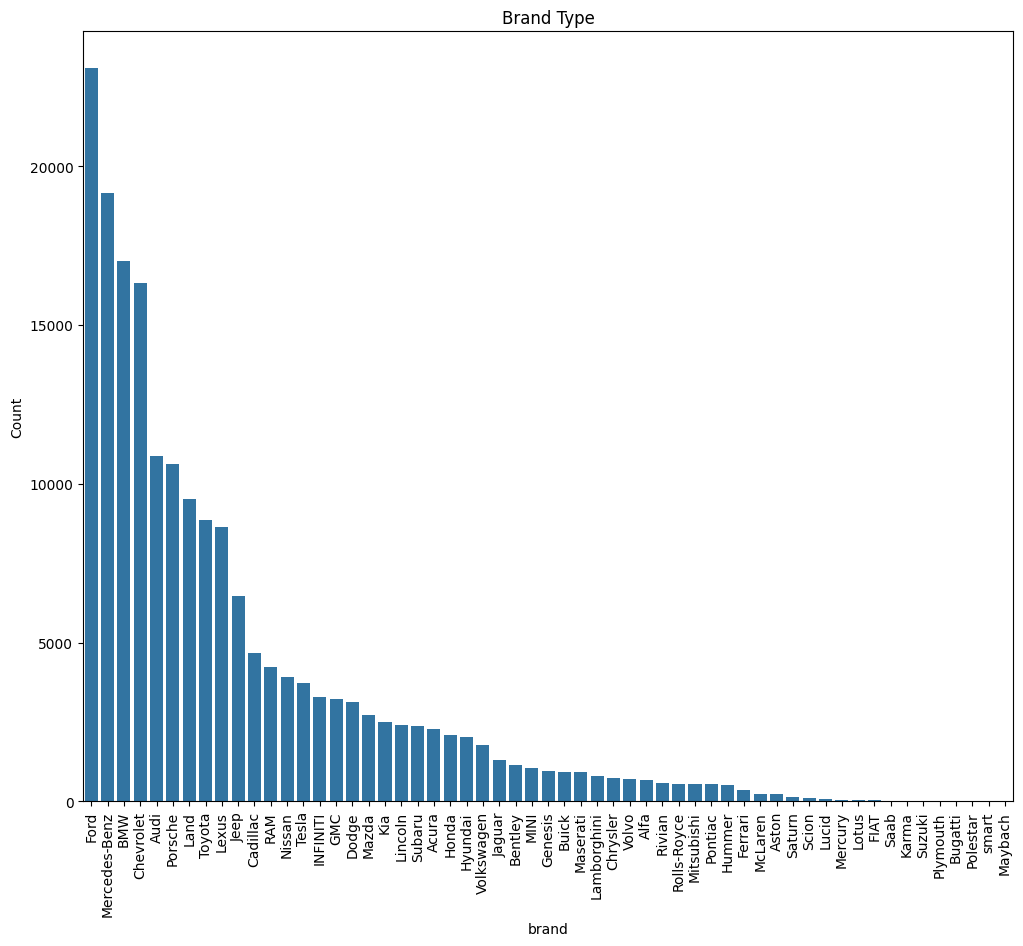

In [ ]:
# Calculate brand counts and sort them
cars_brand_counts = cars['brand'].value_counts().sort_values(ascending=False)

# Create a bar plot using Seaborn with the original data
plt.figure(figsize=(12, 10))
sns.barplot(x=cars_brand_counts.index, y=cars_brand_counts.values)
plt.xlabel('brand')
plt.ylabel('Count')
plt.title('Brand Type')
plt.xticks(rotation=90)
plt.show()


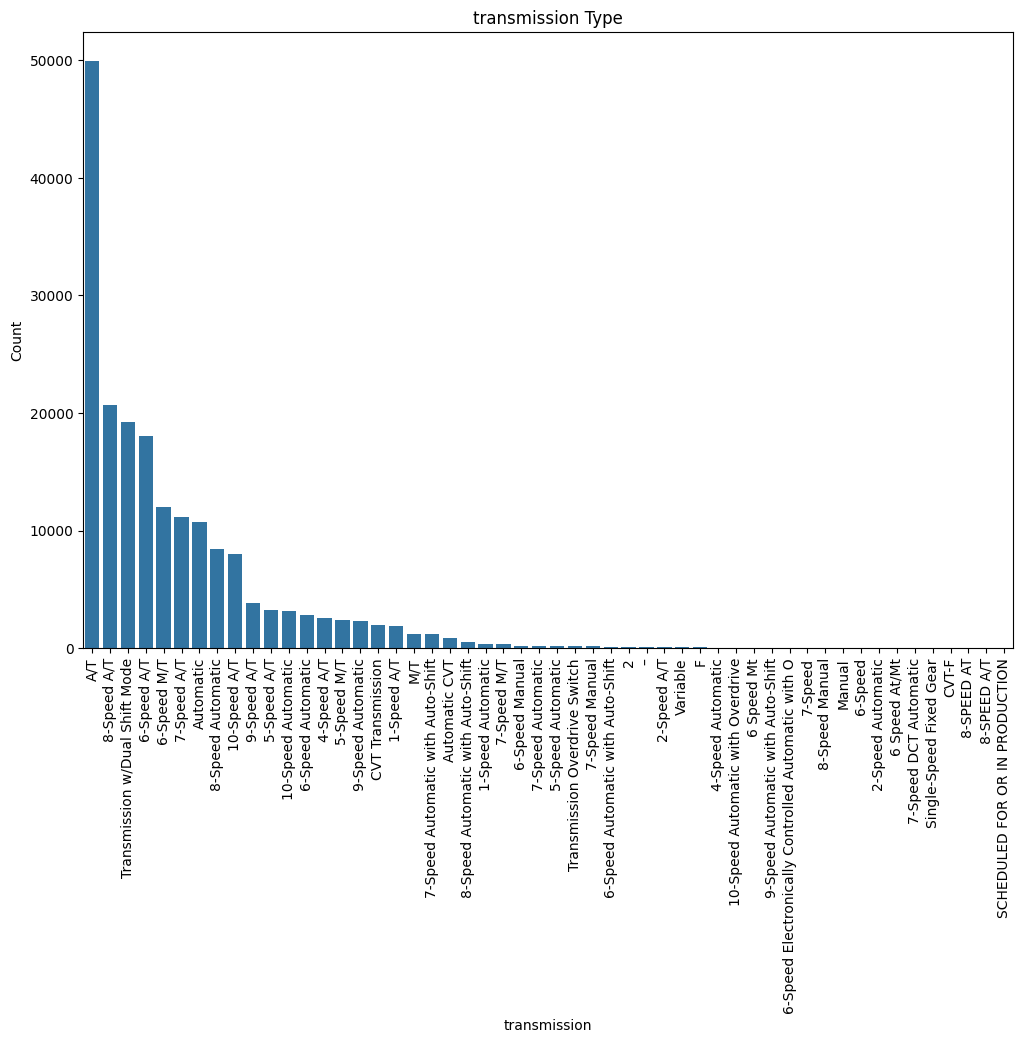

In [ ]:
cars_transmission = cars['transmission'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=cars_transmission.index, y=cars_transmission.values) # Use the original data for Seaborn
plt.xlabel('transmission')
plt.ylabel('Count')
plt.title('transmission Type')
plt.xticks(rotation=90)
plt.show()

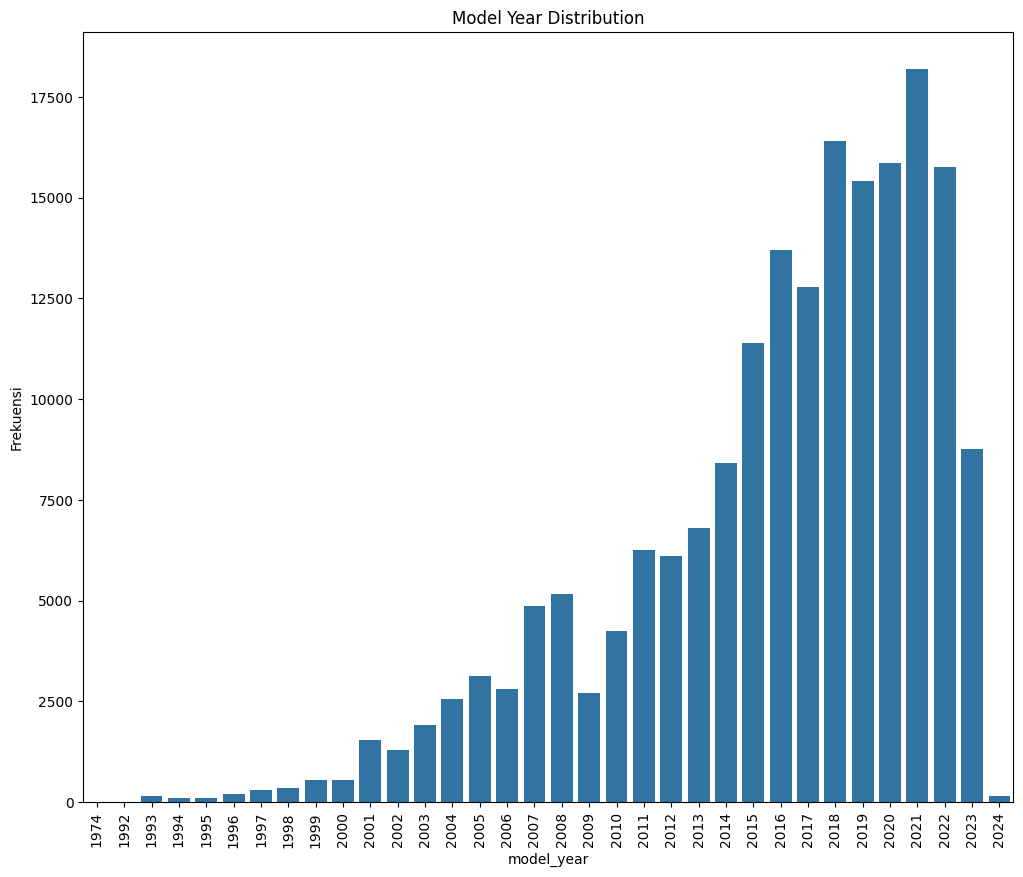

In [ ]:
# Calculate brand counts and sort them
cars_brand_counts = cars['model_year'].value_counts().sort_values(ascending=False)

# Create a bar plot using Seaborn with the original data
plt.figure(figsize=(12, 10))
sns.barplot(x=cars_brand_counts.index, y=cars_brand_counts.values)
plt.xlabel('model_year')
plt.ylabel('Frekuensi')
plt.title('Model Year Distribution')
plt.xticks(rotation=90)
plt.show()


In [ ]:
unique_values_ext = cars['ext_col'].unique()
print(unique_values_ext)

['Yellow' 'Silver' 'Blue' 'Black' 'White' 'Snowflake White Pearl Metallic'
 'Gray' 'Green' 'Santorini Black Metallic' 'Purple'
 'Ebony Twilight Metallic' 'Red' 'Magnetite Black Metallic'
 'Diamond Black' 'Vega Blue' 'Beige' 'Gold' 'Platinum White Pearl'
 'Metallic' 'White Frost Tri-Coat' 'Firecracker Red Clearcoat'
 'Phytonic Blue Metallic' 'Blu' 'Orange' 'Brown'
 'Brilliant Silver Metallic' 'Black Raven' 'Black Clearcoat' 'Firenze Red'
 'Agate Black Metallic' 'Glacial White Pearl' 'Majestic Plum Metallic'
 'designo Diamond White Metallic' 'Oxford White' 'Black Sapphire Metallic'
 'Mythos Black' 'Granite Crystal Clearcoat Metallic'
 'White Diamond Tri-Coat' 'Magnetite Gray Metallic'
 'Carpathian Grey Premium Metallic' 'designo Diamond White Bright'
 'Phantom Black Pearl Effect / Black Roof' 'Nebula Gray Pearl'
 'Deep Crystal Blue Mica' 'Flame Red Clearcoat' 'Lunar Blue Metallic'
 'Bright White Clearcoat' 'Rapid Red Metallic Tinted Clearcoat' 'Caviar'
 'Dark Ash Metallic' 'Velvet Red Pe

In [ ]:
unique_values_int = cars['int_col'].unique()
print(unique_values_int)

['Gray' 'Beige' 'Black' '–' 'Blue' 'White' 'Red' 'Brown' 'Dark Galvanized'
 'Parchment.' 'Boulder' 'Orange' 'Medium Earth Gray' 'Ebony'
 'Canberra Beige' 'Jet Black' 'Silver' 'Light Platinum / Jet Black'
 'Macchiato/Magmagrey' 'Gold' 'Cloud' 'Rioja Red' 'Global Black' 'Green'
 'Medium Stone' 'Navy Pier' 'Dark Ash' 'BLACK' 'Portland' 'Sandstone'
 'Canberra Beige/Black' 'Diesel Gray / Black' 'Sarder Brown' 'Black Onyx'
 'White / Brown' 'Black/Gun Metal' 'Slate' 'Satin Black'
 'Macchiato Beige/Black' 'Charcoal' 'Black / Express Red' 'Cappuccino'
 'Aragon Brown' 'Parchment' 'Oyster W/Contrast' 'Adrenaline Red' 'Ebony.'
 'Shara Beige' 'Graystone' 'Pearl Beige' 'Nero Ade' 'Graphite'
 'Tan/Ebony/Ebony' 'Charcoal Black' 'Medium Ash Gray' 'Ebony Black'
 'Light Titanium' 'Sakhir Orange' 'Tan' 'Rock Gray' 'Brandy'
 'Carbon Black' 'Amber' 'Black w/Red Stitching' 'Hotspur' 'Chateau' 'Ice'
 'Deep Garnet' 'Blk' 'Grace White' 'Oyster/Black' 'Mesa' 'Espresso'
 'Black/Graphite' 'Ebony / Ebony Accents' '

In [ ]:
unique_values_mod = cars['model'].unique()
print(unique_values_mod)

['Cooper S Base' 'LS V8' 'Silverado 2500 LT' ... 'e-Golf SE'
 'Integra w/A-Spec Tech Package' 'IONIQ Plug-In Hybrid SEL']


In [ ]:
unique_values_eng = cars['engine'].unique()
print(unique_values_eng)

['172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel'
 '252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel'
 '320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capability' ...
 '78.0HP 1.2L 3 Cylinder Engine Gasoline Fuel'
 '139.0HP 1.6L 4 Cylinder Engine Plug-In Electric/Gas'
 '313.0HP 2.0L 4 Cylinder Engine Plug-In Electric/Gas']


In [ ]:
print(cars['ext_col'].value_counts())
print(cars['int_col'].value_counts())
print(cars['model'].value_counts())
print(cars['engine'].value_counts())

ext_col
Black                                 48658
White                                 43815
Gray                                  25293
Silver                                16995
Blue                                  14555
                                      ...  
GT SILVER                                 5
Blue Caelum                               5
Granite Crystal Metallic Clearcoat        5
BLUE                                      3
Mango Tango Pearlcoat                     2
Name: count, Length: 319, dtype: int64
int_col
Black           107674
Beige            24495
Gray             21204
Brown             5810
Red               5145
                 ...  
Nougat Brown         7
Classic Red          7
Cobalt Blue          6
WHITE                6
ORANGE               4
Name: count, Length: 156, dtype: int64
model
F-150 XLT                        2945
M3 Base                          2229
Camaro 2SS                       1709
M4 Base                          1622
Mustang GT 

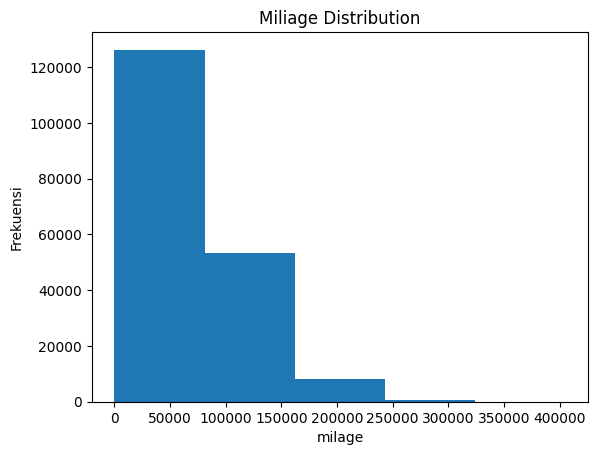

In [ ]:
plt.hist(cars['milage'], bins=5)
plt.xlabel('milage')
plt.ylabel('Frekuensi')
plt.title('Miliage Distribution')
plt.show()

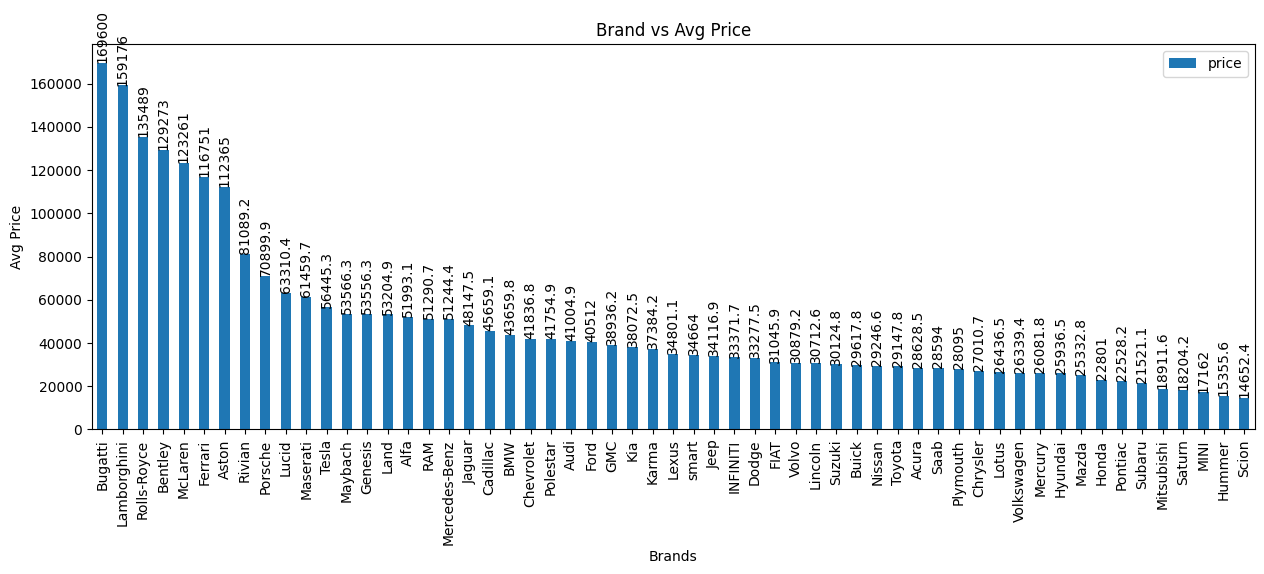

In [ ]:
temp = cars[["brand","price"]].groupby("brand").mean().sort_values("price",ascending = False)
ax = temp.plot(kind="bar", figsize=(15, 5))
for container in ax.containers:
    ax.bar_label(container, rotation = 90)
plt.ylabel("Avg Price")
plt.xlabel("Brands")
plt.title("Brand vs Avg Price");

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     188533 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      188533 non-null  object
 11  clean_title   188533 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


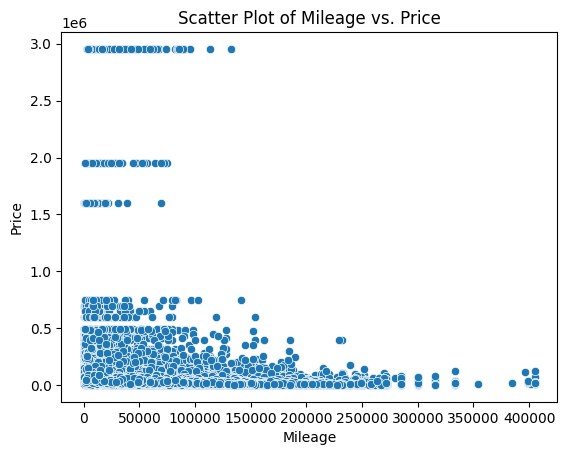

In [ ]:
sns.scatterplot(x='milage', y='price', data=cars)
plt.title('Scatter Plot of Mileage vs. Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [ ]:
categorical_cars =  cars.select_dtypes(include=['object'])
categorical_cars

,brand,model,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,MINI,Cooper S Base,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes
1,Lincoln,LS V8,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes
2,Chevrolet,Silverado 2500 LT,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes
3,Genesis,G90 5.0 Ultimate,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes
4,Mercedes-Benz,Metris Base,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes
...,...,...,...,...,...,...,...,...,...
188528,Cadillac,Escalade ESV Platinum,Gasoline,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Beige,None reported,Yes
188529,Mercedes-Benz,AMG C 43 AMG C 43 4MATIC,Gasoline,385.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,White,Black,At least 1 accident or damage reported,Yes
188530,Mercedes-Benz,AMG GLC 63 Base 4MATIC,Gasoline,469.0HP 4.0L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Black,None reported,Yes
188531,Audi,S5 3.0T Prestige,Gasoline,3.0L,1-Speed Automatic,Daytona Gray Pearl Effect,Black,None reported,No


In [ ]:
label_encoder = LabelEncoder()

for col in categorical_cars:
    cars[col] = label_encoder.fit_transform(cars[col])


In [ ]:
cars

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,31,495,2007,213000,2,116,38,312,71,1,1,4200
1,1,28,930,2002,143250,2,366,38,263,10,0,1,4999
2,2,9,1575,2002,136731,1,640,38,38,71,1,1,13900
3,3,16,758,2017,19500,2,863,49,29,14,1,1,45000
4,4,36,1077,2021,7388,2,259,23,29,10,1,1,97500
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188528,188528,8,604,2017,49000,2,866,49,304,10,1,1,27500
188529,188529,36,206,2018,28600,2,770,31,304,14,0,1,30000
188530,188530,36,223,2021,13650,2,921,23,304,14,1,1,86900
188531,188531,3,1471,2022,13895,2,512,1,82,14,1,0,84900


In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            188533 non-null  int64
 1   brand         188533 non-null  int64
 2   model         188533 non-null  int64
 3   model_year    188533 non-null  int64
 4   milage        188533 non-null  int64
 5   fuel_type     188533 non-null  int64
 6   engine        188533 non-null  int64
 7   transmission  188533 non-null  int64
 8   ext_col       188533 non-null  int64
 9   int_col       188533 non-null  int64
 10  accident      188533 non-null  int64
 11  clean_title   188533 non-null  int64
 12  price         188533 non-null  int64
dtypes: int64(13)
memory usage: 18.7 MB


In [ ]:
X = cars.drop(columns='price', axis=1)
Y = cars['price']

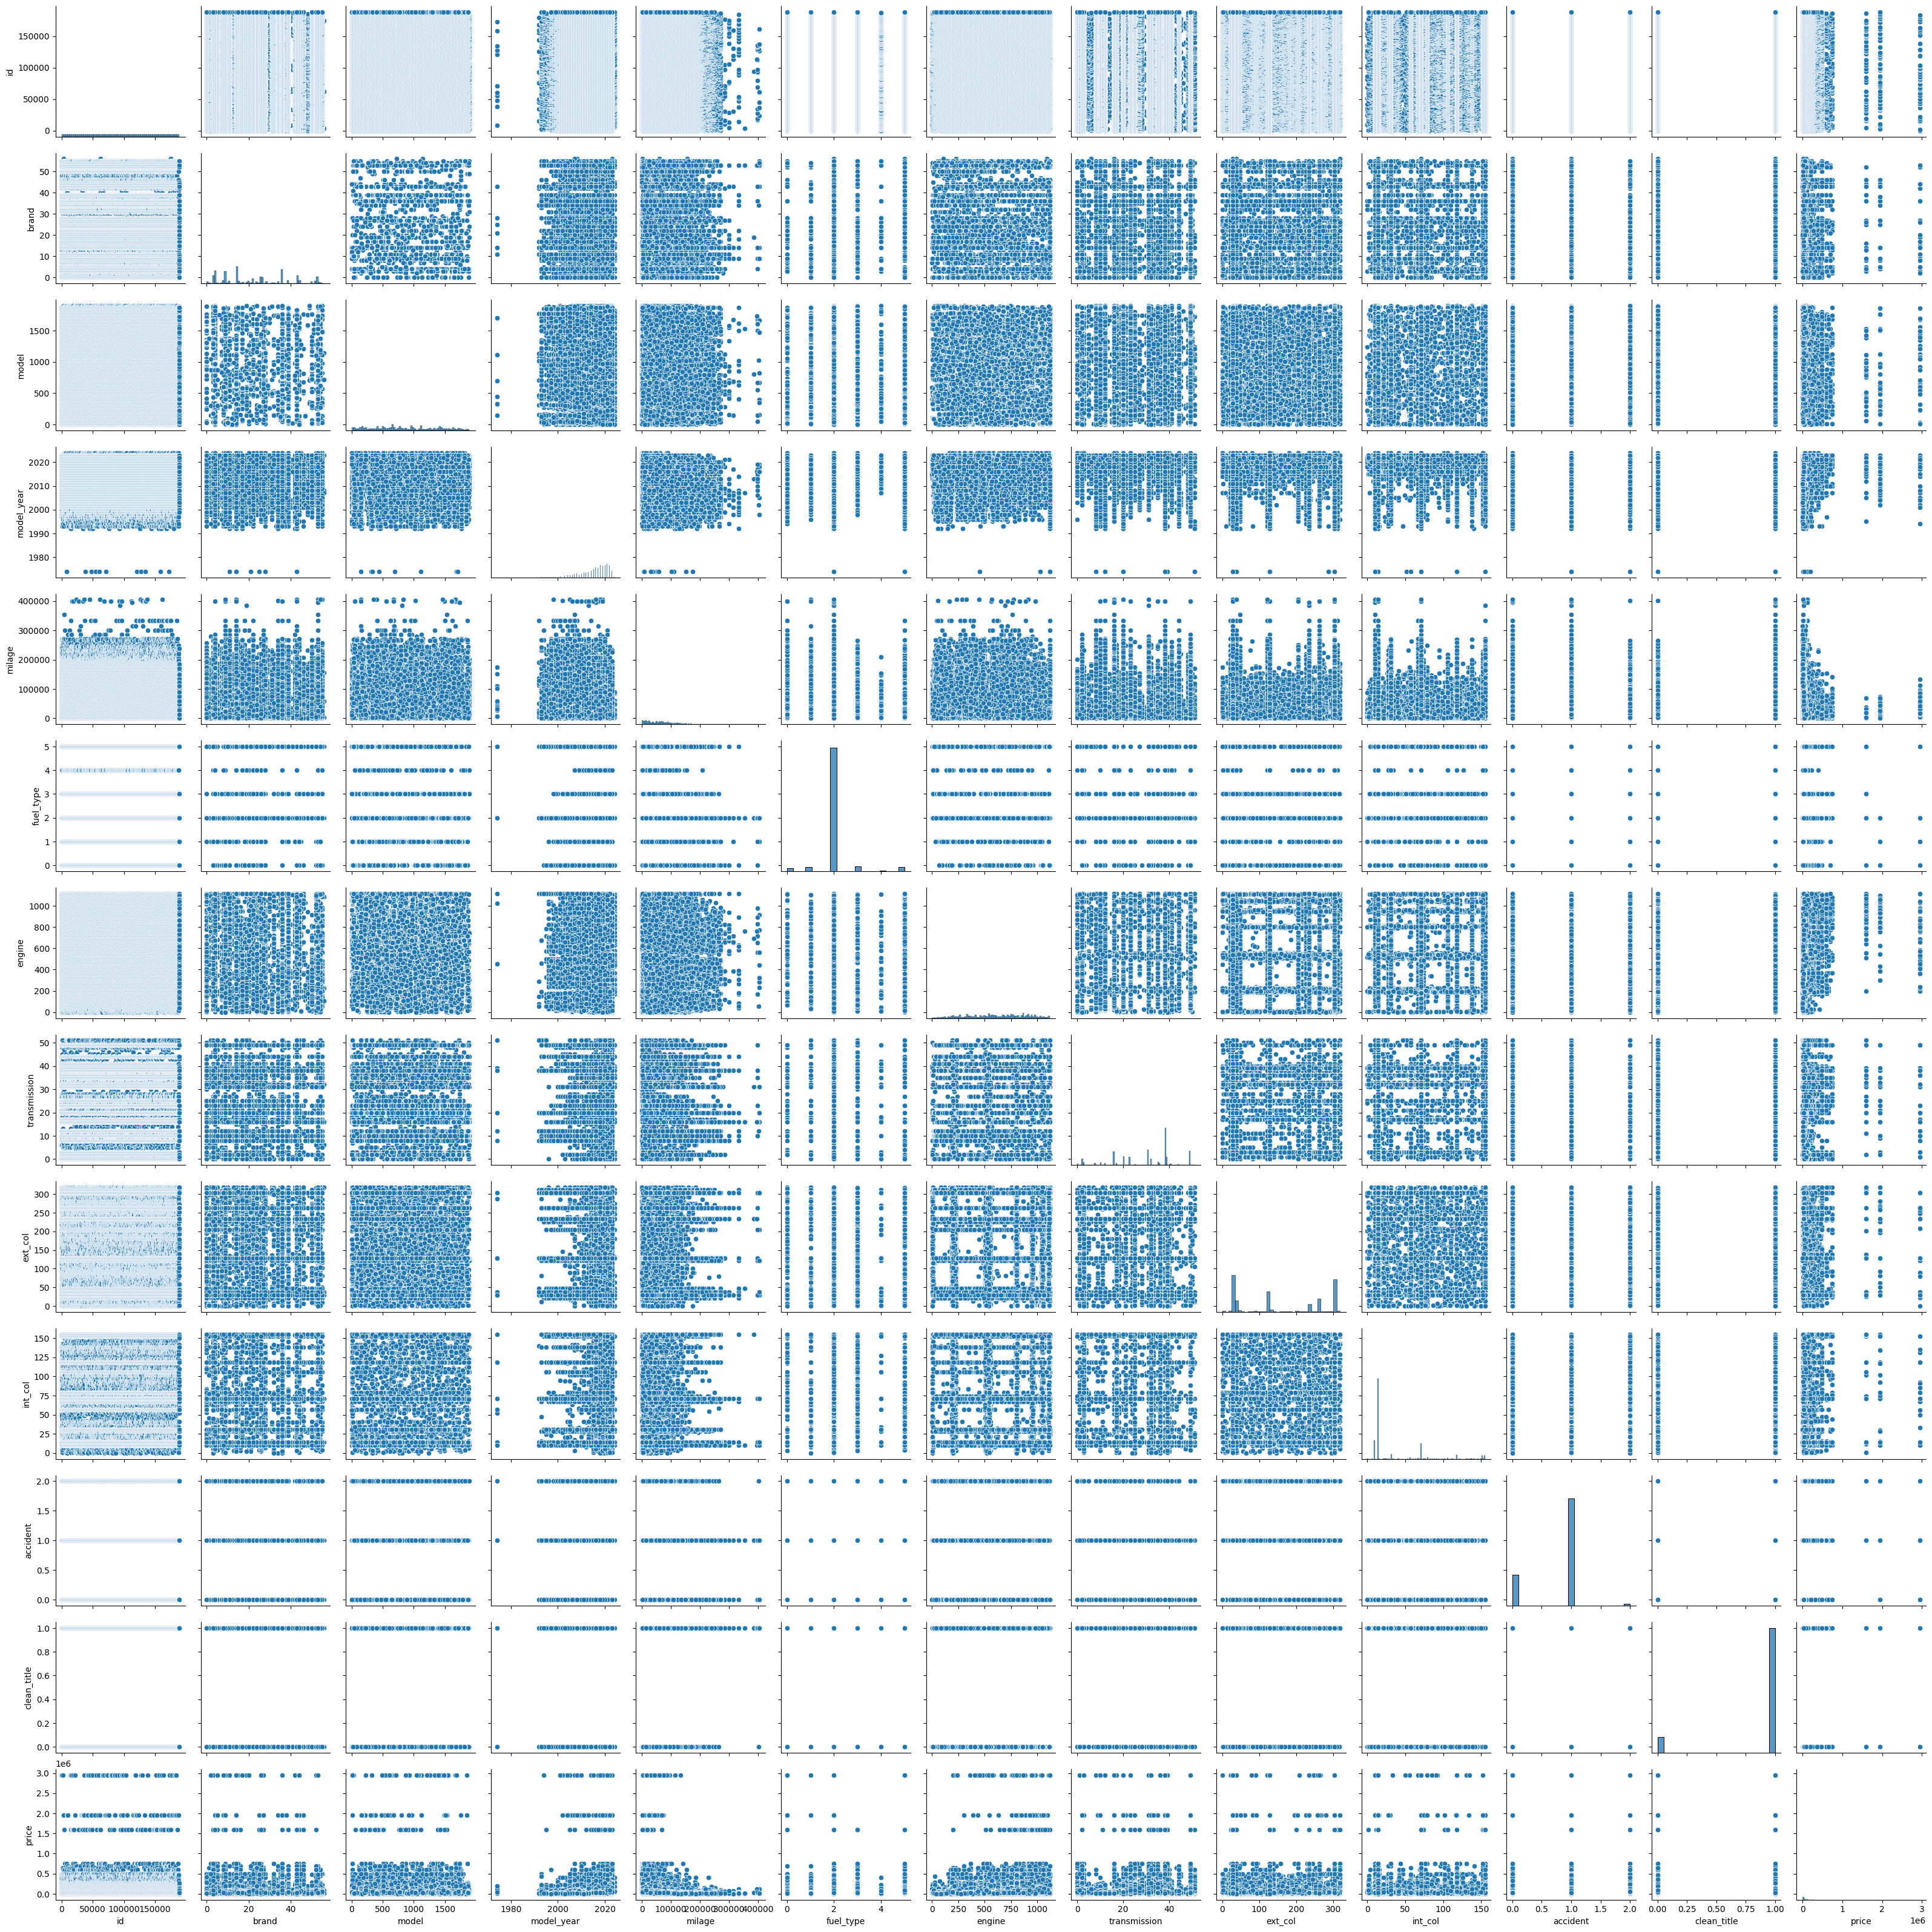

In [ ]:
# Visualisasi menggunakan pairplot (Seaborn)
sns.pairplot(cars)
plt.show()


In [ ]:
# Menghitung matriks korelasi
corr_matrix = cars.corr()
print(corr_matrix)

                    id     brand     model  model_year    milage  fuel_type  \
id            1.000000 -0.000315  0.000184    0.000076 -0.001834   0.002709   
brand        -0.000315  1.000000 -0.040049   -0.014605 -0.007286   0.194012   
model         0.000184 -0.040049  1.000000    0.001784  0.041706   0.065739   
model_year    0.000076 -0.014605  0.001784    1.000000 -0.669936   0.114944   
milage       -0.001834 -0.007286  0.041706   -0.669936  1.000000  -0.166247   
fuel_type     0.002709  0.194012  0.065739    0.114944 -0.166247   1.000000   
engine        0.001962 -0.065512 -0.042079    0.285300 -0.331196   0.134614   
transmission -0.001382  0.036984 -0.027031    0.043596 -0.041158   0.004609   
ext_col      -0.002020  0.006038  0.007560   -0.032189  0.027763  -0.002244   
int_col       0.003013 -0.004765  0.076990    0.024833 -0.030846   0.047620   
accident      0.000700  0.004809 -0.015204    0.251286 -0.314522   0.075222   
clean_title  -0.002355 -0.022153 -0.048268   -0.2648

In [ ]:
cars_X = cars.drop(columns='price', axis=1)
cars_Y = cars['price']

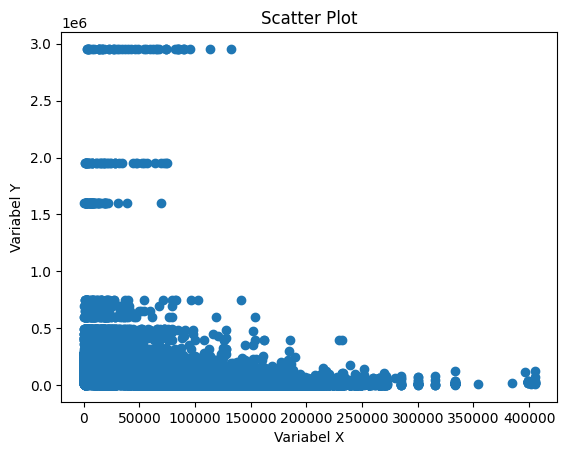

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Membuat scatter plot
plt.scatter(cars['milage'], cars['price'])
plt.xlabel('Variabel X')
plt.ylabel('Variabel Y')
plt.title('Scatter Plot')
plt.show()

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
print('X_train dimension= ', X_train.shape)
print('X_test dimension= ', X_test.shape)
print('Y_train dimension= ', Y_train.shape)
print('Y_test dimension= ', Y_test.shape)

X_train dimension=  (150826, 12)
X_test dimension=  (37707, 12)
Y_train dimension=  (150826,)
Y_test dimension=  (37707,)


In [ ]:

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def evaluate_model(true, predicted):
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    return rmse

In [ ]:
## Beginning Model Training
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(),
    "Xgboost Regressor":XGBRegressor()

}
trained_model={}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, Y_train) # Train model
    trained_model[list(models.keys())[i]] = model
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_valid_pred = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_rmse = evaluate_model(Y_train, y_train_pred)

    model_valid_rmse = evaluate_model(Y_test, y_valid_pred)


    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))

    print('----------------------------------')

    print('Model performance for Validation set')
    print("- Root Mean Squared Error: {:.4f}".format(model_valid_rmse))


    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 75825.2719
----------------------------------
Model performance for Validation set
- Root Mean Squared Error: 70240.2404


Lasso
Model performance for Training set
- Root Mean Squared Error: 75825.2720
----------------------------------
Model performance for Validation set
- Root Mean Squared Error: 70240.2548


Ridge
Model performance for Training set
- Root Mean Squared Error: 75825.2719
----------------------------------
Model performance for Validation set
- Root Mean Squared Error: 70240.2411


Decision Tree
Model performance for Training set
- Root Mean Squared Error: 0.0000
----------------------------------
Model performance for Validation set
- Root Mean Squared Error: 108636.5758


Xgboost Regressor
Model performance for Training set
- Root Mean Squared Error: 57448.9862
----------------------------------
Model performance for Validation set
- Root Mean Squared Error: 70250.7661




In [ ]:
rf = RandomForestClassifier()
rf.fit(X, Y)

# Mendapatkan importance setiap fitur
#importances = rf.feature_importances_

# Mengurutkan fitur berdasarkan importance
#indices = np.argsort(importances)[::-1]

# Membuat plot untuk visualisasi
#plt.figure(figsize=(15,6))
#plt.title("Importance Fitur")
#plt.bar(range(X.shape[1]), importances[indices],
       #color="r", align="center")
#plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90) # Use X.columns for feature names
#plt.xlim([-1, X.shape[1]])
#plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score # Import mean_squared_error and r2_score

lr = LinearRegression()
lr.fit(X_train, Y_train)

# Membuat prediksi pada data test
y_pred = lr.predict(X_test)

# Menghitung RMSE
rmse = np.sqrt(mean_squared_error(Y_test, y_pred)) # Now mean_squared_error is defined
r2 = r2_score(Y_test, y_pred)

print("RMSE:", rmse)
print("R-squared:", r2)

RMSE: 70240.24044286535
R-squared: 0.11282667515960398


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score # Import mean_squared_error and r2_score

xgb = XGBRegressor()
xgb.fit(X_train, Y_train)
# Membuat prediksi pada data test
y_pred = xgb.predict(X_test)

# Menghitung RMSE
rmse = np.sqrt(mean_squared_error(Y_test, y_pred)) # Now mean_squared_error is defined
r2 = r2_score(Y_test, y_pred)

print("RMSE:", rmse)
print("R-squared:", r2)

RMSE: 70250.7661052581
R-squared: 0.1125606894493103


TEST

In [ ]:
# loading the csv data to a Pandas DataFrame
test_cars = pd.read_csv('/content/test.csv')

In [ ]:
test_cars = pd.DataFrame(test_cars)

In [ ]:
test_cars

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,188533,Land,Rover LR2 Base,2015,98000,Gasoline,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Beige,None reported,Yes
1,188534,Land,Rover Defender SE,2020,9142,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Silver,Black,None reported,Yes
2,188535,Ford,Expedition Limited,2022,28121,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,White,Ebony,None reported,NaN
3,188536,Audi,A6 2.0T Sport,2016,61258,Gasoline,2.0 Liter TFSI,Automatic,Silician Yellow,Black,None reported,NaN
4,188537,Audi,A6 2.0T Premium Plus,2018,59000,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
125685,314218,Mercedes-Benz,GL-Class GL 450 4MATIC,2014,83315,Gasoline,362.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Black,None reported,Yes
125686,314219,Audi,Q7 55 Prestige,2019,29336,Gasoline,3.0 Liter Turbo,Automatic,White,Black,None reported,NaN
125687,314220,Audi,A6 3.0T Premium Plus,2012,77634,Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes
125688,314221,Audi,Q7 3.0T Premium,2012,112000,Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes


In [ ]:
test_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125690 entries, 0 to 125689
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            125690 non-null  int64 
 1   brand         125690 non-null  object
 2   model         125690 non-null  object
 3   model_year    125690 non-null  int64 
 4   milage        125690 non-null  int64 
 5   fuel_type     122307 non-null  object
 6   engine        125690 non-null  object
 7   transmission  125690 non-null  object
 8   ext_col       125690 non-null  object
 9   int_col       125690 non-null  object
 10  accident      124058 non-null  object
 11  clean_title   111451 non-null  object
dtypes: int64(3), object(9)
memory usage: 11.5+ MB


CEK MISSING VALUE

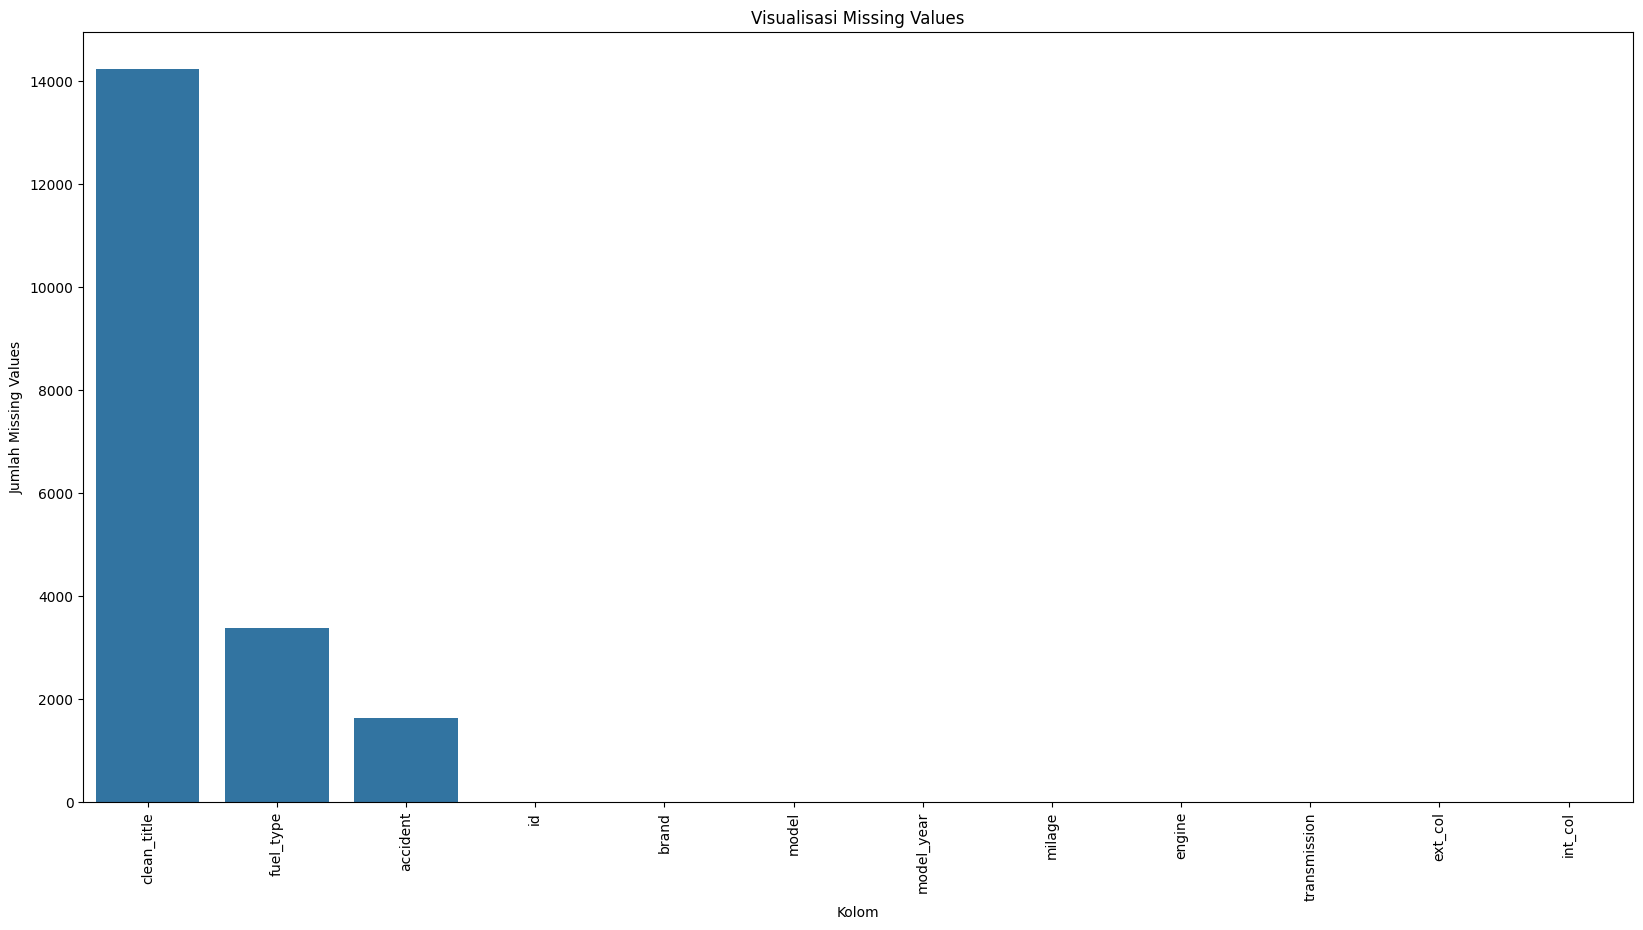

In [ ]:

# Menghitung jumlah missing values per kolom
missing_val = test_cars.isnull().sum().sort_values(ascending=False)

# Membuat bar plot untuk visualisasi
plt.figure(figsize=(20, 10))
sns.barplot(x=missing_val.index, y=missing_val.values)
plt.xlabel('Kolom')
plt.ylabel('Jumlah Missing Values')
plt.title('Visualisasi Missing Values')
plt.xticks(rotation=90)
plt.show()

HANDLING MISSING VALUE

In [ ]:
test_cars["accident"] = test_cars["accident"].fillna("unknown data")
test_cars["clean_title"] = test_cars["clean_title"].fillna("No")
test_cars['fuel_type'] = test_cars['fuel_type'].fillna('–')

In [ ]:
test_cars.replace({'fuel_type': {'–': 'not supported'}}, inplace=True)
print(test_cars)

            id          brand                   model  model_year  milage  \
0       188533           Land          Rover LR2 Base        2015   98000   
1       188534           Land       Rover Defender SE        2020    9142   
2       188535           Ford      Expedition Limited        2022   28121   
3       188536           Audi           A6 2.0T Sport        2016   61258   
4       188537           Audi    A6 2.0T Premium Plus        2018   59000   
...        ...            ...                     ...         ...     ...   
125685  314218  Mercedes-Benz  GL-Class GL 450 4MATIC        2014   83315   
125686  314219           Audi          Q7 55 Prestige        2019   29336   
125687  314220           Audi    A6 3.0T Premium Plus        2012   77634   
125688  314221           Audi         Q7 3.0T Premium        2012  112000   
125689  314222      Chevrolet                Tahoe LT        2018   66840   

       fuel_type                                             engine  \
0   

In [ ]:
test_cars

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,188533,Land,Rover LR2 Base,2015,98000,Gasoline,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Beige,None reported,Yes
1,188534,Land,Rover Defender SE,2020,9142,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Silver,Black,None reported,Yes
2,188535,Ford,Expedition Limited,2022,28121,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,White,Ebony,None reported,No
3,188536,Audi,A6 2.0T Sport,2016,61258,Gasoline,2.0 Liter TFSI,Automatic,Silician Yellow,Black,None reported,No
4,188537,Audi,A6 2.0T Premium Plus,2018,59000,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
125685,314218,Mercedes-Benz,GL-Class GL 450 4MATIC,2014,83315,Gasoline,362.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Black,None reported,Yes
125686,314219,Audi,Q7 55 Prestige,2019,29336,Gasoline,3.0 Liter Turbo,Automatic,White,Black,None reported,No
125687,314220,Audi,A6 3.0T Premium Plus,2012,77634,Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes
125688,314221,Audi,Q7 3.0T Premium,2012,112000,Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes


In [ ]:
categorical_testcars =  test_cars.select_dtypes(include=['object'])
categorical_testcars

,brand,model,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,Land,Rover LR2 Base,Gasoline,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Beige,None reported,Yes
1,Land,Rover Defender SE,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Silver,Black,None reported,Yes
2,Ford,Expedition Limited,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,White,Ebony,None reported,No
3,Audi,A6 2.0T Sport,Gasoline,2.0 Liter TFSI,Automatic,Silician Yellow,Black,None reported,No
4,Audi,A6 2.0T Premium Plus,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes
...,...,...,...,...,...,...,...,...,...
125685,Mercedes-Benz,GL-Class GL 450 4MATIC,Gasoline,362.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Black,None reported,Yes
125686,Audi,Q7 55 Prestige,Gasoline,3.0 Liter Turbo,Automatic,White,Black,None reported,No
125687,Audi,A6 3.0T Premium Plus,Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes
125688,Audi,Q7 3.0T Premium,Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes


In [ ]:
label_encoder = LabelEncoder()

for col in categorical_testcars:
    test_cars[col] = label_encoder.fit_transform(test_cars[col])


In [ ]:
test_cars

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,188533,26,1388,2015,98000,2,326,16,302,10,1,1
1,188534,26,1375,2020,9142,3,787,31,261,14,1,1
2,188535,14,636,2022,28121,2,541,3,302,57,1,0
3,188536,3,182,2016,61258,2,193,39,259,14,1,0
4,188537,3,181,2018,59000,2,365,38,127,14,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
125685,314218,36,759,2014,83315,2,732,23,29,14,1,1
125686,314219,3,1248,2019,29336,2,511,39,302,14,1,0
125687,314220,3,184,2012,77634,2,673,38,29,14,1,1
125688,314221,3,1244,2012,112000,2,673,38,29,14,1,1


PREDICT

In [ ]:
test_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125690 entries, 0 to 125689
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            125690 non-null  int64
 1   brand         125690 non-null  int64
 2   model         125690 non-null  int64
 3   model_year    125690 non-null  int64
 4   milage        125690 non-null  int64
 5   fuel_type     125690 non-null  int64
 6   engine        125690 non-null  int64
 7   transmission  125690 non-null  int64
 8   ext_col       125690 non-null  int64
 9   int_col       125690 non-null  int64
 10  accident      125690 non-null  int64
 11  clean_title   125690 non-null  int64
dtypes: int64(12)
memory usage: 11.5 MB


In [ ]:
# Now you can predict
predicted_carspricelr = lr.predict(test_cars)
test_cars['price'] = predicted_carspricelr
test_cars[['id', 'price']].to_csv('used cars price using linear regression.csv', index=False)

In [ ]:
# loading the csv data to a Pandas DataFrame
predicted_carspricelr = pd.read_csv('/content/used cars price using linear regression.csv')

predict_linearregression = pd.DataFrame(predicted_carspricelr)
predict_linearregression

,id,price
0,188533,19570.282503
1,188534,65101.370301
2,188535,63743.986179
3,188536,34465.984880
4,188537,36242.346143
...,...,...
125685,314218,42326.141091
125686,314219,55214.283267
125687,314220,37572.127962
125688,314221,24537.053593


In [ ]:
test_cars

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,188533,26,1388,2015,98000,2,326,16,302,10,1,1,19570.282503
1,188534,26,1375,2020,9142,3,787,31,261,14,1,1,65101.370301
2,188535,14,636,2022,28121,2,541,3,302,57,1,0,63743.986179
3,188536,3,182,2016,61258,2,193,39,259,14,1,0,34465.984880
4,188537,3,181,2018,59000,2,365,38,127,14,1,1,36242.346143
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125685,314218,36,759,2014,83315,2,732,23,29,14,1,1,42326.141091
125686,314219,3,1248,2019,29336,2,511,39,302,14,1,0,55214.283267
125687,314220,3,184,2012,77634,2,673,38,29,14,1,1,37572.127962
125688,314221,3,1244,2012,112000,2,673,38,29,14,1,1,24537.053593


In [ ]:
# Now you can predict
predicted_carspricexgb = xgb.predict(test_cars.drop(columns=['price'])) # Drop the 'price' column before prediction
test_cars['price'] = predicted_carspricexgb
test_cars[['id', 'price']].to_csv('used cars price using XGB.csv', index=False)

In [ ]:
# loading the csv data to a Pandas DataFrame
predicted_carspricexgb = pd.read_csv('//content/used cars price using XGB.csv')

predict_xgb = pd.DataFrame(predicted_carspricexgb)
predict_xgb

,id,price
0,188533,13876.664
1,188534,94055.734
2,188535,52249.914
3,188536,83382.470
4,188537,27375.658
...,...,...
125685,314218,26050.973
125686,314219,41330.640
125687,314220,21156.810
125688,314221,15311.720


In [ ]:
from matplotlib import pyplot as plt
predict['SalePrice'].plot(kind='hist', bins=20, title='SalePrice')
plt.gca().spines[['top', 'right',]].set_visible(False)